# Análise das exportações de Fibras e Produtos Têxteis no RS por Porto/URF (2015–2025)

Notebook adaptado no mesmo formato das análises anteriores, usando o arquivo `data_RS_Fibras-Prod-Têxteis.xlsx`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

arquivo = "data_RS_Fibras-Prod-Têxteis.xlsx"

base_normalizada = pd.read_excel(arquivo, sheet_name="base_normalizada")

jaguarao = pd.read_excel(arquivo, sheet_name="(URF) 1010252 - JAGUARAO")

bage = pd.read_excel(arquivo, sheet_name="(URF) 1010253 - BAGE")

santana_do_livramento = pd.read_excel(arquivo, sheet_name="(URF) 1010351 - IRF SANTANA DO")

uruguaiana = pd.read_excel(arquivo, sheet_name="(URF) 1010900 - URUGUAIANA")

sao_borja = pd.read_excel(arquivo, sheet_name="(URF) 1010953 - SAO BORJA")

chui = pd.read_excel(arquivo, sheet_name="(URF) 1015500 - CHUI")

santana_do_livramento2 = pd.read_excel(arquivo, sheet_name="(URF) 1015600 - SANTANA DO LIVR")

uruguaiana2 = pd.read_excel(arquivo, sheet_name="(URF) 1017500 - ALF - URUGUAIAN")

sao_borja2 = pd.read_excel(arquivo, sheet_name="(URF) 1017503 - IRF - SÃO BORJA")

aeroporto_salgado = pd.read_excel(arquivo, sheet_name="(URF) 1017600 - AEROPORTO SALGA")

rio_grande = pd.read_excel(arquivo, sheet_name="(URF) 1017700 - PORTO DE RIO GR")

chui2 = pd.read_excel(arquivo, sheet_name="(URF) 1017701 - IRF - CHUÍ")

porto_alegre = pd.read_excel(arquivo, sheet_name="(URF) 1017800 - ALF - PORTO ALE")

aeroporto_salgado2 = pd.read_excel(arquivo, sheet_name="(URF) 1017801 - IRF - AEROPORTO")

santana_do_livramento3 = pd.read_excel(arquivo, sheet_name="(URF) 1017900 - ALF - SANTANA D")


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re

arquivo = "data_RS_Fibras-Prod-Têxteis.xlsx"
abas = pd.read_excel(arquivo, sheet_name=None)

nomes_portos = {
    "1010252": "1010252 - Jaguarão",
    "1010253": "1010253 - Bagé",
    "1010351": "1010351 - IRF Santana do Livramento",
    "1010900": "1010900 - Uruguaiana",
    "1010953": "1010953 - São Borja",
    "1015500": "1015500 - Chuí",
    "1015600": "1015600 - Santana do Livramento",
    "1017500": "1017500 - ALF Uruguaiana",
    "1017503": "1017503 - IRF São Borja",
    "1017600": "1017600 - Aeroporto Salgado Filho",
    "1017700": "1017700 - Porto de Rio Grande",
    "1017701": "1017701 - IRF Chuí",
    "1017800": "1017800 - ALF Porto Alegre",
    "1017801": "1017801 - IRF Aeroporto Salgado Filho",
    "1017900": "1017900 - ALF Santana do Livramento"
}

lista_dfs = []

for nome_aba, df in abas.items():
    df = df.copy()

    codigo_match = re.search(r"\d{7}", nome_aba)
    if codigo_match:
        codigo = codigo_match.group()
        df["Porto_URF"] = nomes_portos.get(codigo, f"{codigo} - Nome não mapeado")
        lista_dfs.append(df)

base = pd.concat(lista_dfs, ignore_index=True)

base["Peso_KG"] = pd.to_numeric(base["Peso_KG"], errors="coerce").fillna(0)
base["Valor_USD"] = pd.to_numeric(base["Valor_USD"], errors="coerce").fillna(0)
base["Ano"] = pd.to_numeric(base["Ano"], errors="coerce")

# Agrupar por ano e Porto/URF
df_porto_ano = (
    base
    .groupby(["Ano", "Porto_URF"], as_index=False)["Peso_KG"]
    .sum()
)

df_porto_ano["Peso_milhoes"] = df_porto_ano["Peso_KG"] / 1_000_000

df_porto_ano.head()


,Ano,Porto_URF,Peso_KG,Peso_milhoes
0,2015,1010252 - Jaguarão,528997.0,0.528997
1,2015,1010253 - Bagé,0.0,0.000000
2,2015,1010351 - IRF Santana do Livramento,0.0,0.000000
3,2015,1010900 - Uruguaiana,1957704.0,1.957704
4,2015,1010953 - São Borja,3452.0,0.003452


In [3]:
resumo_urf = (
    base
    .groupby("Porto_URF", as_index=False)["Peso_KG"]
    .sum()
    .sort_values("Peso_KG", ascending=False)
)
resumo_urf["Percentual"] = resumo_urf["Peso_KG"] / resumo_urf["Peso_KG"].sum() * 100
resumo_urf


,Porto_URF,Peso_KG,Percentual
2,1010351 - IRF Santana do Livramento,58553914.0,28.789153
6,1015600 - Santana do Livramento,37509933.0,18.442477
7,1017500 - ALF Uruguaiana,34033979.0,16.733457
14,1017900 - ALF Santana do Livramento,27044979.0,13.297182
10,1017700 - Porto de Rio Grande,17883694.0,8.792861
0,1010252 - Jaguarão,8726935.0,4.290765
11,1017701 - IRF Chuí,7871221.0,3.870037
3,1010900 - Uruguaiana,6844423.0,3.365192
8,1017503 - IRF São Borja,2393995.0,1.177053
5,1015500 - Chuí,2136928.0,1.050662


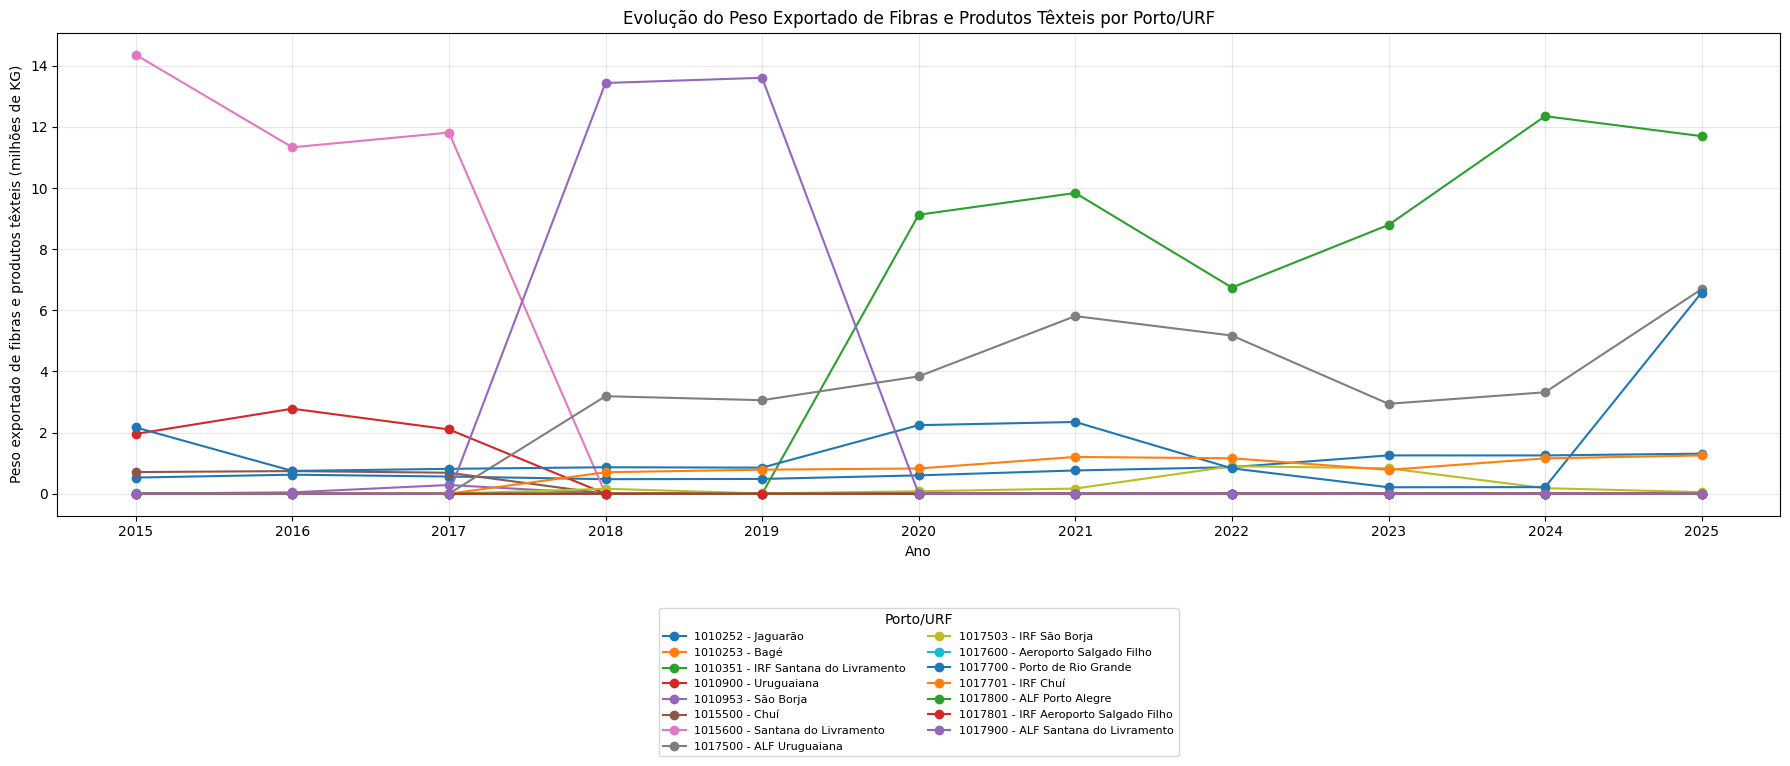

In [4]:
grafico = df_porto_ano.copy()

tabela_grafico = grafico.pivot(
    index="Ano",
    columns="Porto_URF",
    values="Peso_milhoes"
).fillna(0)

plt.figure(figsize=(18, 8))

for porto in tabela_grafico.columns:
    plt.plot(
        tabela_grafico.index,
        tabela_grafico[porto],
        marker="o",
        label=porto
    )

plt.title("Evolução do Peso Exportado de Fibras e Produtos Têxteis por Porto/URF")
plt.xlabel("Ano")
plt.ylabel("Peso exportado de fibras e produtos têxteis (milhões de KG)")
plt.xticks(tabela_grafico.index)

plt.legend(
    title="Porto/URF",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=2,
    fontsize=8
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


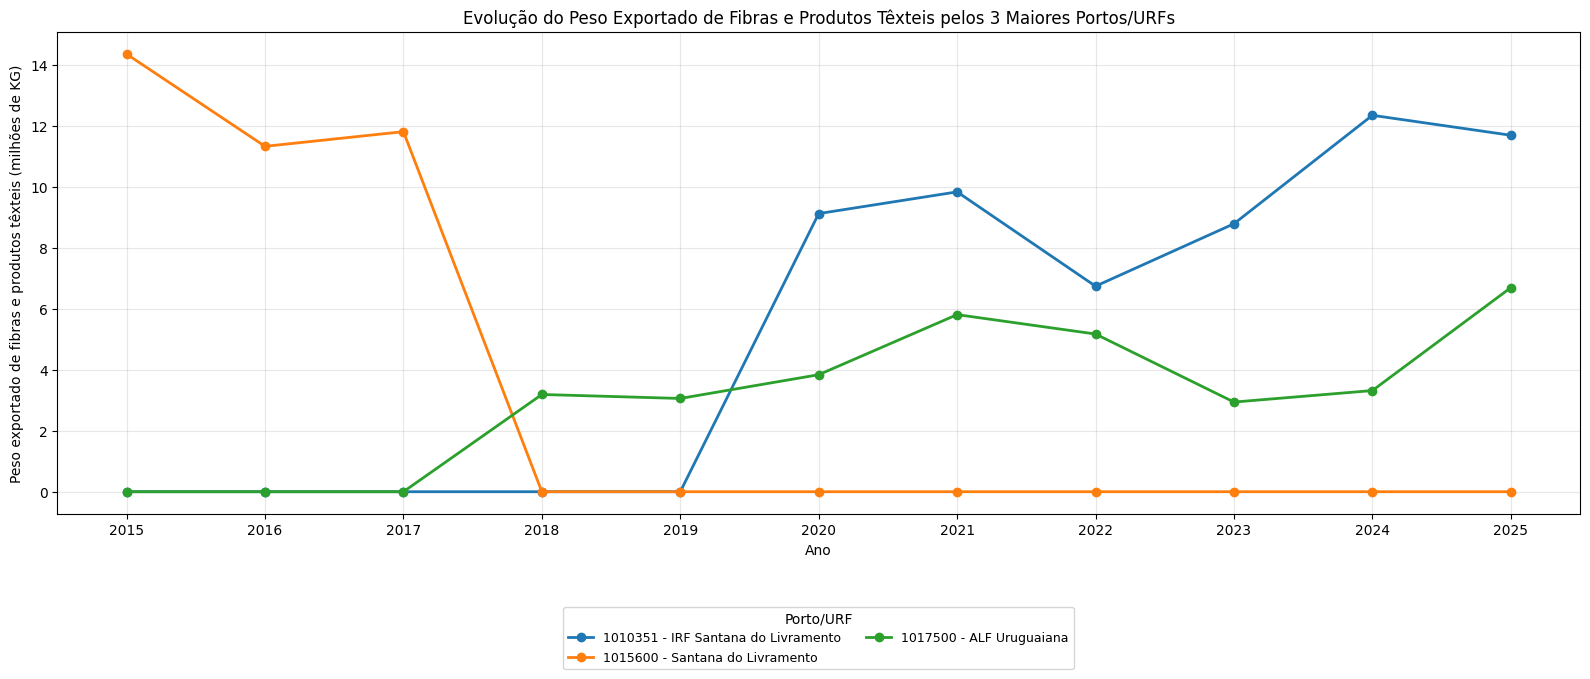

In [5]:
grafico = df_porto_ano.copy()

# Identificar os 3 maiores exportadores no total do período
top3_portos = (
    grafico
    .groupby("Porto_URF")["Peso_milhoes"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

# Filtrar apenas o Top 3
grafico_top3 = grafico[grafico["Porto_URF"].isin(top3_portos)]

# Criar tabela para o gráfico
tabela_grafico = grafico_top3.pivot_table(
    index="Ano",
    columns="Porto_URF",
    values="Peso_milhoes",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(16, 7))

for porto in tabela_grafico.columns:
    plt.plot(
        tabela_grafico.index,
        tabela_grafico[porto],
        marker="o",
        linewidth=2,
        label=porto
    )

plt.title("Evolução do Peso Exportado de Fibras e Produtos Têxteis pelos 3 Maiores Portos/URFs")
plt.xlabel("Ano")
plt.ylabel("Peso exportado de fibras e produtos têxteis (milhões de KG)")
plt.xticks(tabela_grafico.index)

plt.legend(
    title="Porto/URF",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=2,
    fontsize=9
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


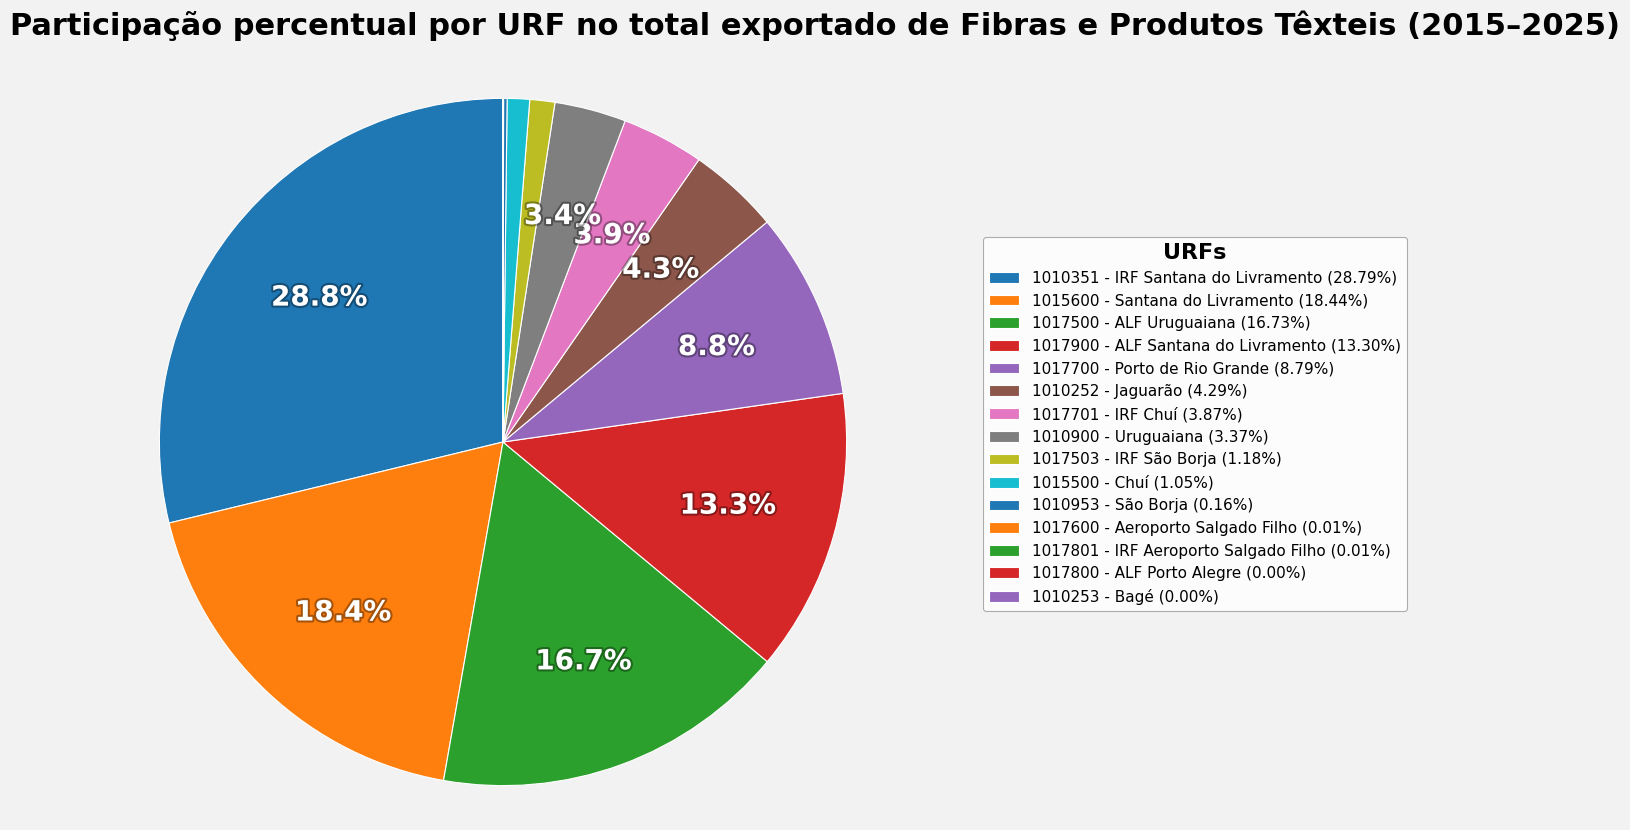

In [6]:
import matplotlib.patheffects as path_effects

participacao = (
    base
    .groupby("Porto_URF", as_index=False)["Peso_KG"]
    .sum()
    .sort_values("Peso_KG", ascending=False)
)
participacao["Percentual"] = participacao["Peso_KG"] / participacao["Peso_KG"].sum() * 100

labels = [f"{row.Porto_URF} ({row.Percentual:.2f}%)" for row in participacao.itertuples()]
values = participacao["Peso_KG"]

fig = plt.figure(figsize=(16, 9), facecolor="#f2f2f2")
ax = fig.add_axes([0.03, 0.06, 0.55, 0.84], facecolor="#f2f2f2")

def autopct_func(pct):
    return f"{pct:.1f}%" if pct >= 3 else ""

wedges, texts, autotexts = ax.pie(
    values,
    startangle=90,
    counterclock=True,
    autopct=autopct_func,
    pctdistance=0.68,
    wedgeprops={"linewidth": 0.8, "edgecolor": "white"},
    textprops={"color": "white", "fontsize": 20, "weight": "bold"},
)

for txt in autotexts:
    txt.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground="black", alpha=0.35),
        path_effects.Normal()
    ])

ax.axis("equal")

fig.suptitle(
    "Participação percentual por URF no total exportado de Fibras e Produtos Têxteis (2015–2025)",
    fontsize=22,
    fontweight="bold",
    y=0.96,
)

legend = fig.legend(
    wedges,
    labels,
    title="URFs",
    loc="center left",
    bbox_to_anchor=(0.60, 0.50),
    frameon=True,
    fontsize=11,
    title_fontsize=16,
)
legend.get_title().set_weight("bold")
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#999999")
legend.get_frame().set_linewidth(0.8)

plt.savefig("participacao_percentual_urf_fibras_prod_texteis.png", dpi=150, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()
